Processing the LFW Dataset with a CNN - 2026-06-07 - halarc1407

In [1]:
import warnings
warnings.filterwarnings('ignore')

### Load and Explore the Dataset

Date: 2026-06-07

Student ID: halarc1407

Data shape: (1288, 1850)
Number of classes: 7
Classes: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


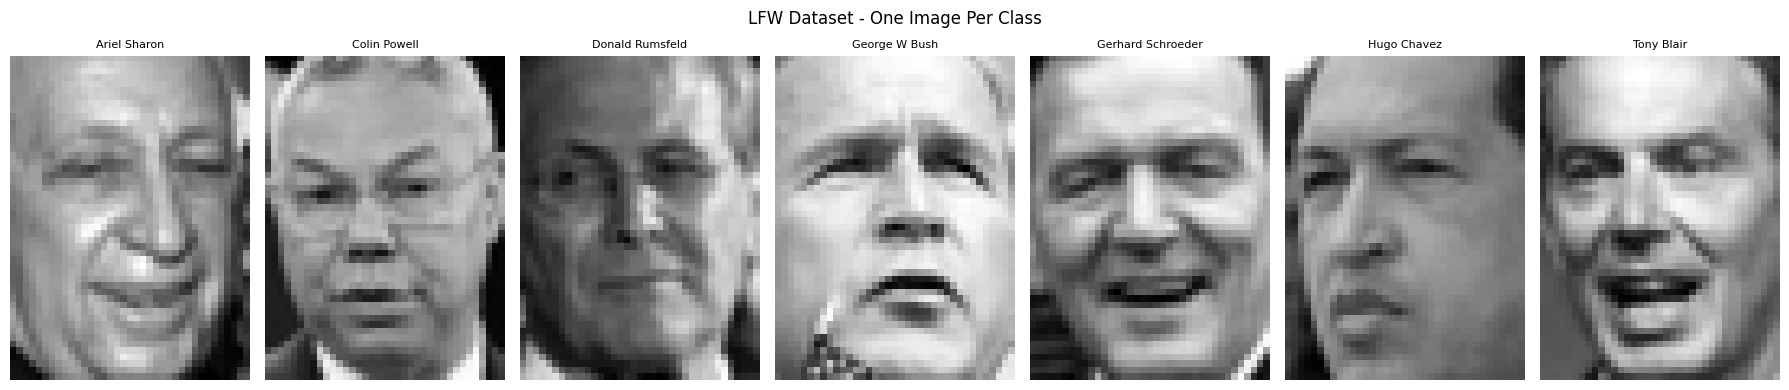

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from datetime import datetime
from IPython.display import display, Markdown

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "halarc1407"

display(Markdown("### Load and Explore the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Load the LFW dataset
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
data = lfw_people.data
target = lfw_people.target
target_names = lfw_people.target_names

print(f"Data shape: {data.shape}")
print(f"Number of classes: {len(target_names)}")
print(f"Classes: {target_names}")

# Display original images
fig, axes = plt.subplots(1, 7, figsize=(18, 4))
for i, ax in enumerate(axes):
    # Show one representative image per class
    idx = np.where(target == i)[0][0]
    ax.imshow(data[idx].reshape(50, 37), cmap='gray')
    ax.set_title(target_names[i], fontsize=8)
    ax.axis('off')
plt.suptitle('LFW Dataset - One Image Per Class')
plt.tight_layout()
plt.show()

In [3]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

display(Markdown("### Preprocess the Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Normalize pixel values
data = data / 255.0

# Min and max pixel values as additional features
min_pixel_values = np.min(data, axis=1).reshape(-1, 1)
max_pixel_values = np.max(data, axis=1).reshape(-1, 1)

# Concatenate new features with original data
data_with_features = np.hstack((data, min_pixel_values, max_pixel_values))
print(f"Data shape with engineered features: {data_with_features.shape}")

# 70/30 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    data_with_features, target, test_size=0.3, random_state=42
)

# Convert target to categorical
y_train_cat = tf.keras.utils.to_categorical(y_train, len(target_names))
y_test_cat = tf.keras.utils.to_categorical(y_test, len(target_names))

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train_cat.shape}")
print(f"y_test shape:  {y_test_cat.shape}")

### Preprocess the Data

Date: 2026-06-07

Student ID: halarc1407

Data shape with engineered features: (1288, 1852)
X_train shape: (901, 1852)
X_test shape:  (387, 1852)
y_train shape: (901, 7)
y_test shape:  (387, 7)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

display(Markdown("### Construct and Train the CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Build model per spec: 128 -> Dropout -> 64 -> Dropout -> 7
model = Sequential([
    Input(shape=(data_with_features.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
history = model.fit(X_train, y_train_cat, epochs=20, batch_size=32, validation_split=0.2)

print("\nTraining complete.")

### Construct and Train the CNN Model

Date: 2026-06-07

Student ID: halarc1407

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       237,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245,895 (960.53 KB)

 Trainable params: 245,895 (960.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3694 - loss: 1.9006 - val_accuracy: 0.4088 - val_loss: 1.8185
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4000 - loss: 1.7695 - val_accuracy: 0.4088 - val_loss: 1.6886
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4028 - loss: 1.7301 - val_accuracy: 0.4088 - val_loss: 1.6667
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4028 - loss: 1.7487 - val_accuracy: 0.4088 - val_loss: 1.6729
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4028 - loss: 1.7435 - val_accuracy: 0.4088 - val_loss: 1.6703
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4028 - loss: 1.7391 - val_accuracy: 0.4088 - val_loss: 1.6619
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4028 - loss: 1.7297 - val_accuracy: 0.4088 - val_loss: 1.6639
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4028 - loss: 1.7306 - val_accuracy: 0.4088 - val_loss:

### Evaluate the CNN Model

Date: 2026-06-07

Student ID: halarc1407

Test accuracy: 0.4289
Test loss:     1.6355
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


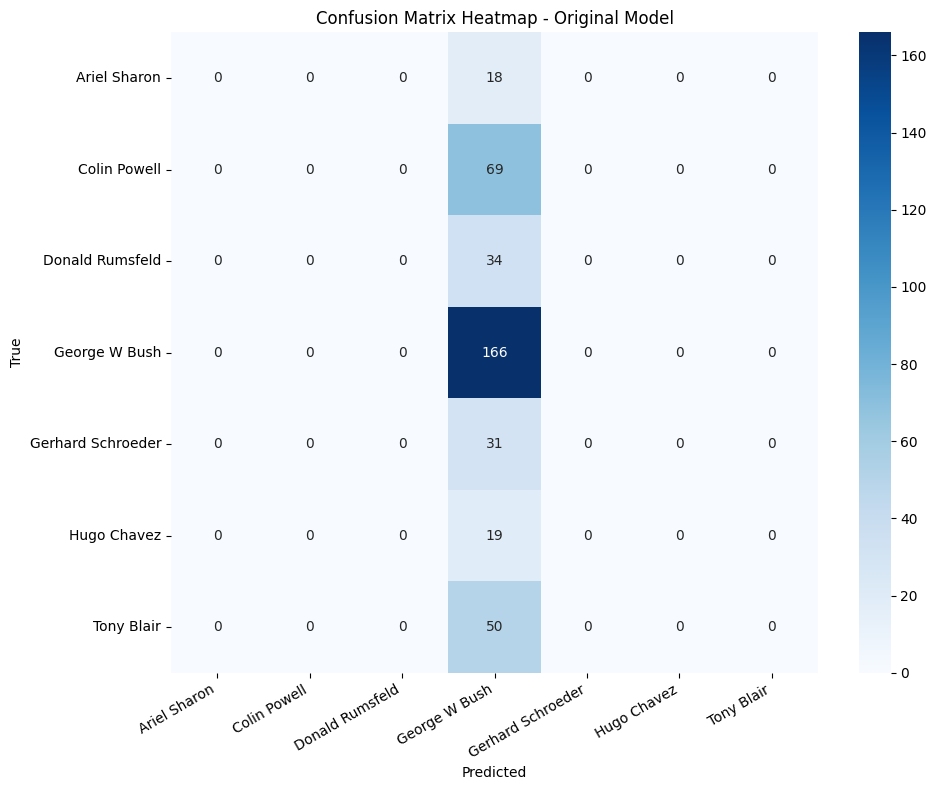

In [5]:
import seaborn as sns

display(Markdown("### Evaluate the CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Confusion matrix heatmap
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap - Original Model')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [6]:
from sklearn.decomposition import PCA

display(Markdown("### Apply PCA for CNN Model Tuning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# PCA with n_components=150, whiten=True
pca = PCA(n_components=150, whiten=True, random_state=42)
data_pca = pca.fit_transform(data)

# Min and max pixel values on PCA-transformed data
min_pca = np.min(data_pca, axis=1).reshape(-1, 1)
max_pca = np.max(data_pca, axis=1).reshape(-1, 1)

# Concatenate
data_pca_features = np.hstack((data_pca, min_pca, max_pca))
print(f"PCA data shape with engineered features: {data_pca_features.shape}")

# 70/30 split on adjusted data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    data_pca_features, target, test_size=0.3, random_state=42
)

y_train_pca_cat = tf.keras.utils.to_categorical(y_train_pca, len(target_names))
y_test_pca_cat = tf.keras.utils.to_categorical(y_test_pca, len(target_names))

# Build PCA model per spec: 256 -> Dropout -> 128 -> Dropout -> 7
pca_model = Sequential([
    Input(shape=(data_pca_features.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

pca_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
pca_model.summary()

### Apply PCA for CNN Model Tuning

Date: 2026-06-07

Student ID: halarc1407

PCA data shape with engineered features: (1288, 152)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        39,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,967 (285.03 KB)

 Trainable params: 72,967 (285.03 KB)

 Non-trainable params: 0 (0.00 B)

### Evaluate the Adjusted CNN Model

Date: 2026-06-07

Student ID: halarc1407

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3014 - loss: 2.2191 - val_accuracy: 0.4751 - val_loss: 1.5995
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3819 - loss: 1.7477 - val_accuracy: 0.4862 - val_loss: 1.5257
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4444 - loss: 1.6073 - val_accuracy: 0.5083 - val_loss: 1.4651
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4917 - loss: 1.4253 - val_accuracy: 0.5414 - val_loss: 1.3807
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5347 - loss: 1.2905 - val_accuracy: 0.5967 - val_loss: 1.2715
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6069 - loss: 1.1255 - val_accuracy: 0.5912 - val_loss: 1.1742
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6403 - loss: 1.0093 - val_accuracy: 0.6575 - val_loss: 1.0717
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7208 - loss: 0.8914 - val_accuracy: 0.6906 - val_loss:

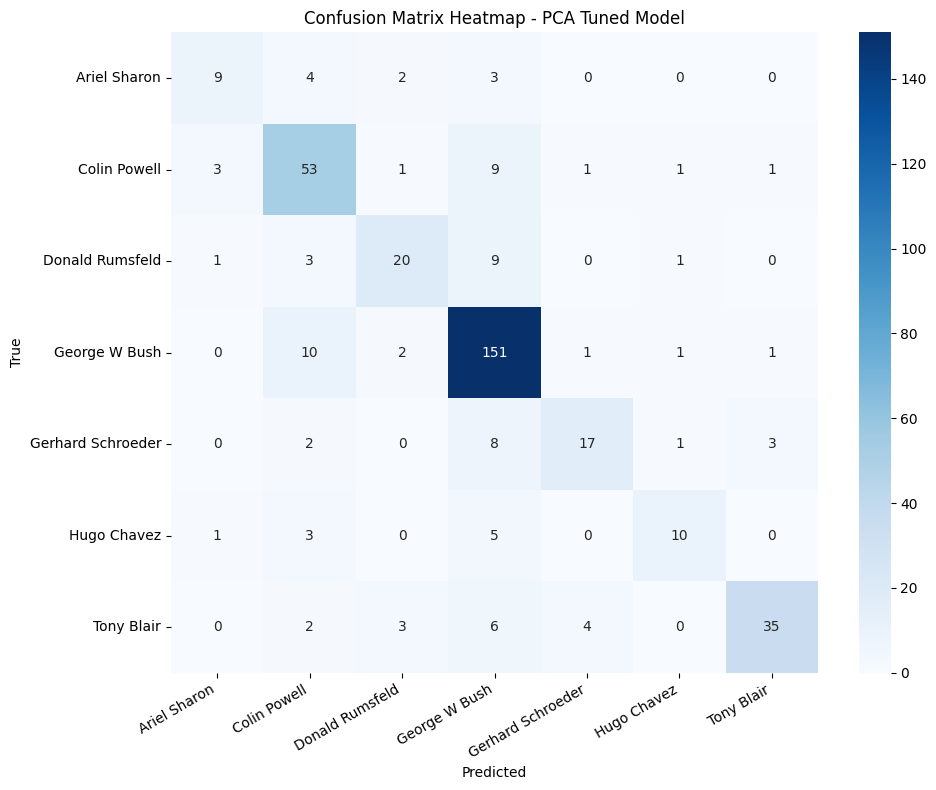

In [7]:
display(Markdown("### Evaluate the Adjusted CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Train the PCA model
pca_history = pca_model.fit(X_train_pca, y_train_pca_cat, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate
pca_test_loss, pca_test_acc = pca_model.evaluate(X_test_pca, y_test_pca_cat, verbose=0)
print(f"PCA Model Test accuracy: {pca_test_acc:.4f}")
print(f"PCA Model Test loss:     {pca_test_loss:.4f}")

# Predictions
y_pca_pred = pca_model.predict(X_test_pca)
y_pca_pred_classes = np.argmax(y_pca_pred, axis=1)
y_pca_true = np.argmax(y_test_pca_cat, axis=1)

# Confusion matrix heatmap
pca_confusion_mtx = tf.math.confusion_matrix(y_pca_true, y_pca_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(pca_confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap - PCA Tuned Model')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Compare Performance of the CNN Models

Date: 2026-06-07

Student ID: halarc1407

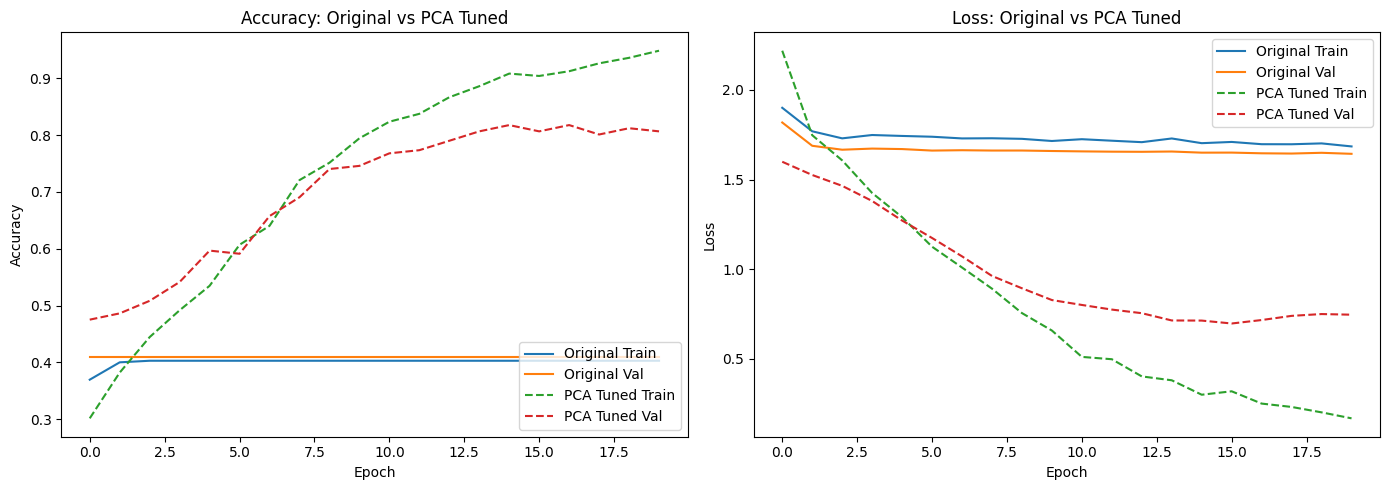

In [8]:
display(Markdown("### Compare Performance of the CNN Models"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history.history['accuracy'], label='Original Train')
axes[0].plot(history.history['val_accuracy'], label='Original Val')
axes[0].plot(pca_history.history['accuracy'], label='PCA Tuned Train', linestyle='--')
axes[0].plot(pca_history.history['val_accuracy'], label='PCA Tuned Val', linestyle='--')
axes[0].set_title('Accuracy: Original vs PCA Tuned')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='lower right')

# Loss comparison
axes[1].plot(history.history['loss'], label='Original Train')
axes[1].plot(history.history['val_loss'], label='Original Val')
axes[1].plot(pca_history.history['loss'], label='PCA Tuned Train', linestyle='--')
axes[1].plot(pca_history.history['val_loss'], label='PCA Tuned Val', linestyle='--')
axes[1].set_title('Loss: Original vs PCA Tuned')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()